# Esame Laboratorio di Programmazione II - 11/09/2025


Scrivete chiaramente sul notebook il vostro nome e matricola e sul nome con cui salvate il file la vostra matricola.

Per ogni funzione e metodo che richiede un campionamento rispetto ad una distribuzione settate il seed a 0: ``np.random.seed(0)``.

Stampate il risultato delle domanda e consegnate il compito eseguito, quindi per cui ogni cella ha il corrispondente output.
Quindi ad esempio

e.g., 
NON scrivete: 
```python 
    lista=np.array([1,2,3])
```
ma 
```python
    lista=np.array([1,2,3]) 
    print('lista =', lista)   
```
Attenzione!Se scrivete:
```python
    lista=np.array([1,2,3])
    lista
```
``lista`` sarà l'unico ouput che si vede di quella cella

NB se l'output è una matrice molto grande non dovete stamparla.

Sarà valutata anche la presentazione, ad esempio un plot senza ettichette sugli assi o illleggibili sarà valutato meno bene di uno con ettichette chiare.

Commentate il compito di modo che si capisca cosa avete fatto.

Controllate attentamente di avere consegnato il file giusto.

In [2]:
#Potete importare direttamente qui le librerie che userete
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Esercizio 1

Un’azienda ha registrato i **costi mensili di trasporto** (in euro) per 9 mezzi:  
450, 720, 1200, 980, 510, 1500, 640, 890, 2000  

1. Calcola la **spesa totale complessiva**.  

2. I mezzi con spesa **inferiore a 700 €** ricevono un **bonus di efficienza del 10%** (cioè la spesa viene ridotta del 10%).  

3. Stampa il **risparmio totale** ottenuto dall’azienda.


In [6]:
prezzi = np.array([450, 720, 1200, 980, 510, 1500, 640, 890, 2000])
spesa = prezzi.sum()
prezzi_bonus = np.where(prezzi < 700, prezzi*0.9, prezzi)
risparmio = spesa - prezzi_bonus.sum()

print(f"Prezzi: {prezzi}\nSpesa: {spesa}\nPrezzi con bonus: {prezzi_bonus}\nRisparmio totale: {risparmio}")

Prezzi: [ 450  720 1200  980  510 1500  640  890 2000]
Spesa: 8890
Prezzi con bonus: [ 405.  720. 1200.  980.  459. 1500.  576.  890. 2000.]
Risparmio totale: 160.0


## Esercizio 2

Un’urna contiene **4 palline verdi** e **1 pallina gialla**.  
Dopo ogni estrazione la pallina viene **rimessa nell’urna**.  

1. Scrivi una funzione che simula **N estrazioni** e rappresenta i risultati con un array NumPy (`1 = verde`, `0 = gialla`).  

2. Calcola la **frequenza relativa** delle palline verdi e gialle dopo 20, 40, 60, …, 200 estrazioni.  

3. Rappresenta graficamente l’**andamento della frequenza relativa di verdi e gialle** in funzione del numero di estrazioni.


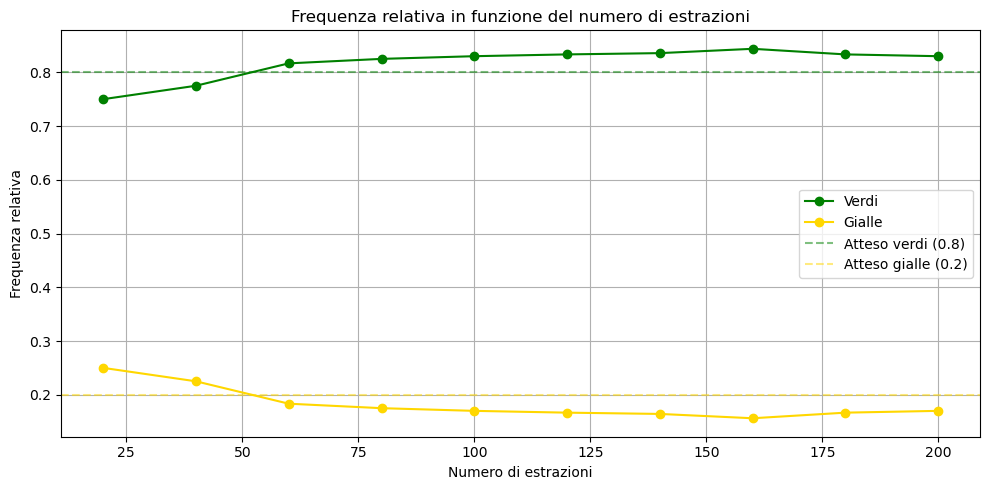

In [7]:
def estrazioni(n):
    estrazioni = np.random.choice([0,1], size = n, p = [1/5, 4/5])

    intervalli = np.arange(20, 201, 20)
    f_verdi = [np.mean(estrazioni[:i]) for i in intervalli]
    f_gialle = [1 - f for f in f_verdi]

    return (estrazioni, f_verdi, f_gialle, intervalli)

risultati, f_verdi, f_gialle, intervalli = estrazioni(200)

plt.figure(figsize=(10, 5))
plt.plot(intervalli, f_verdi, marker='o', color='green', label='Verdi')
plt.plot(intervalli, f_gialle, marker='o', color='gold', label='Gialle')
plt.axhline(y=4/5, color='green', linestyle='--', alpha=0.5, label='Atteso verdi (0.8)')
plt.axhline(y=1/5, color='gold', linestyle='--', alpha=0.5, label='Atteso gialle (0.2)')
plt.title('Frequenza relativa in funzione del numero di estrazioni')
plt.xlabel('Numero di estrazioni')
plt.ylabel('Frequenza relativa')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Esercizio 3

1. Genera una matrice NumPy di dimensioni **5 x 7**, con valori interi casuali compresi tra 10 e 99 (inclusi).  

2. Per ogni riga, seleziona e stampa il **numero pari più grande**.  


In [10]:
matrice = np.random.randint(10, 100, size=(5,7))

for i,riga in enumerate(matrice):
    pari = riga[riga % 2 == 0]

    if(len(pari) > 0):
        print(f"Riga {i}: {max(pari)}")
    else:
        print(f"Nessun numero pari nella riga {i}")

Riga 0: 48
Nessun numero pari nella riga 1
Riga 2: 74
Riga 3: 62
Riga 4: 64


## Esercizio 4

Utilizza il dataset `tips.csv` (contiene colonne come `total_bill`, `tip`, `sex`, `smoker`, `day`, `time`, `size`).  

1. Conta i **valori mancanti per colonna** ed elimina le righe con valori mancanti.  

2. Crea una nuova colonna `tip_ratio` definita come:  

   \[
   \texttt{tip\_ratio} = \frac{\texttt{tip}}{\texttt{total\_bill}}
   \]  

   *(Indica la percentuale di mancia rispetto al conto totale).*  

3. **Filtra** i conti con:  
   - `total_bill` > 30  
   - `tip_ratio` > 0.15  

4. **Grafico a barre** dei **10 clienti con tip_ratio più alto** (usa l’indice del DataFrame come etichetta).  

5. **Scatter plot** con:  
   - x = `total_bill`  
   - y = `tip`  
   - colore dei punti = `tip_ratio`.  


Valori mancanti per colonna:
total_bill    0
tip           1
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

Righe dopo filtro: 8


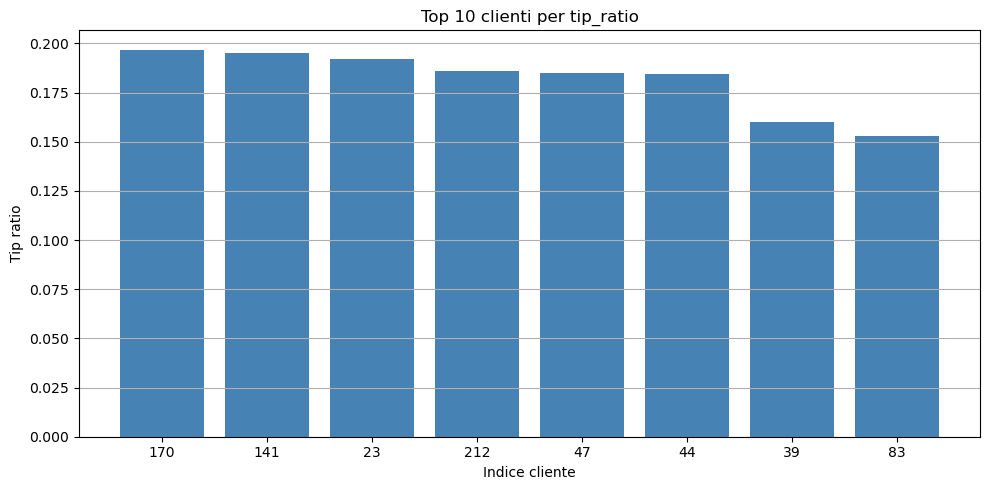

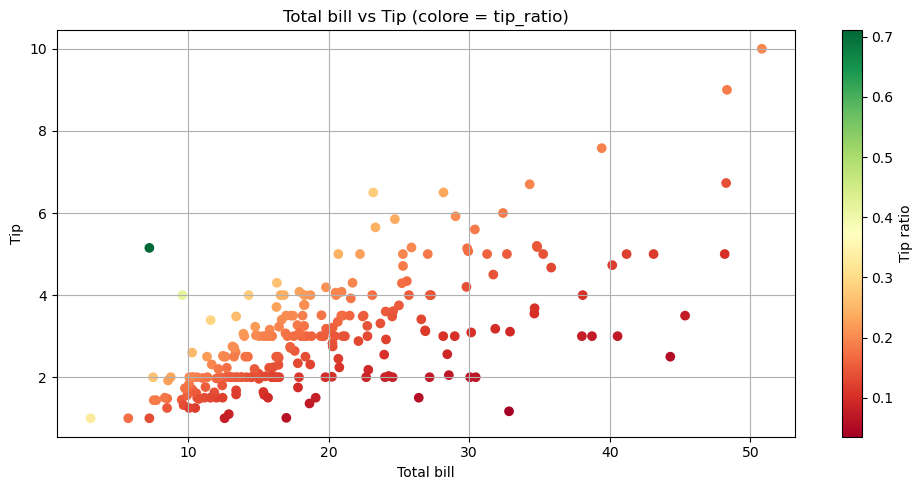

In [16]:
tips = pd.read_csv("tips.csv")
tips.head()

# 1
print('Valori mancanti per colonna:')
print(tips.isnull().sum())
tips = tips.dropna()

# 2
tips['tip_ratio'] = tips['tip']/tips['total_bill']

# 3
tips_filtrato = tips[(tips['total_bill'] > 30) & (tips['tip_ratio'] > 0.15)]
print(f"\nRighe dopo filtro: {len(tips_filtrato)}")

# 4. Grafico a barre top 10 tip_ratio
top10 = tips_filtrato.nlargest(10, 'tip_ratio')
plt.figure(figsize=(10, 5))
plt.bar(top10.index.astype(str), top10['tip_ratio'], color='steelblue')
plt.title('Top 10 clienti per tip_ratio')
plt.xlabel('Indice cliente')
plt.ylabel('Tip ratio')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# 5. Scatter plot
plt.figure(figsize=(10, 5))
scatter = plt.scatter(tips['total_bill'], tips['tip'], c=tips['tip_ratio'], cmap='RdYlGn')
plt.colorbar(scatter, label='Tip ratio')
plt.title('Total bill vs Tip (colore = tip_ratio)')
plt.xlabel('Total bill')
plt.ylabel('Tip')
plt.grid(True)
plt.tight_layout()
plt.show()

## Esercizio 5

Utilizza il dataset `tips.csv`.  

1. Quante **righe e colonne** ha il dataset? Successivamente elimina la colonna `time` dal DataFrame.  
2. Trova il **giorno (`day`) più frequente** nel dataset.  
3. Calcola la **media del conto totale (`total_bill`) per ciascun giorno** e ordina i risultati.  
4. Crea un **boxplot** dei valori di `tip` raggruppati per giorno (`day`).  
5. Crea un **violin plot** della distribuzione del `tip_ratio` (mancia/conto) per ciascun giorno della settimana.  

Bonus (Per i punti 4 e 5 dividere i risultati anche per sesso)

Righe: 243, Colonne: 8

Giorno più frequente: Sat

Media total_bill per giorno:
day
Fri     17.151579
Thur    17.682742
Sat     20.441379
Sun     21.462667
Name: total_bill, dtype: float64


C:\Users\Viola\AppData\Local\Temp\ipykernel_13912\1208362405.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=giorni)
C:\Users\Viola\AppData\Local\Temp\ipykernel_13912\1208362405.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=giorni)


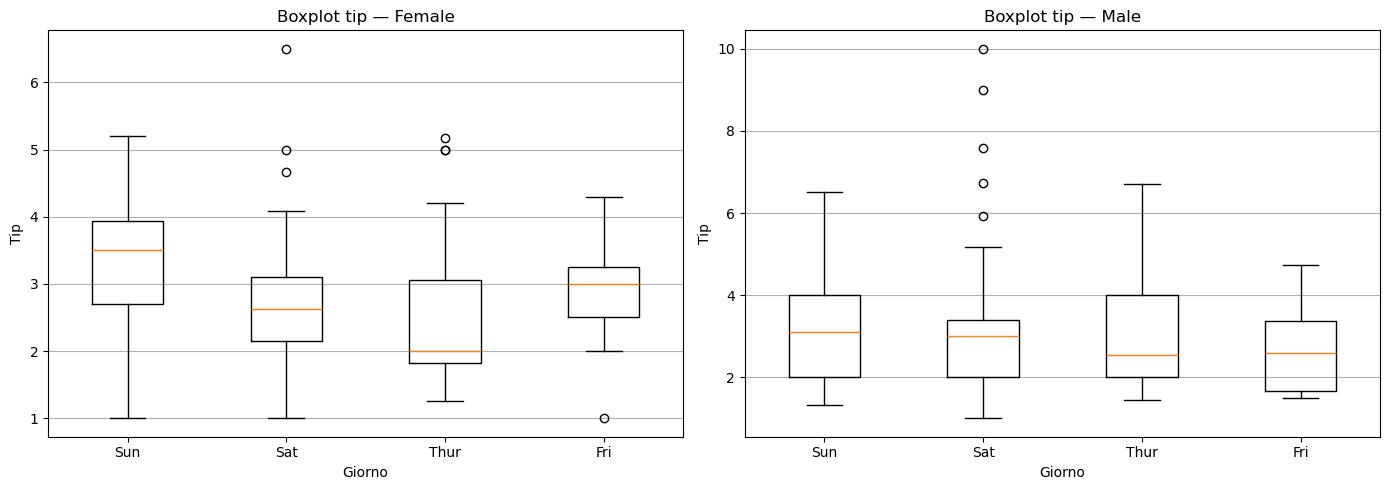

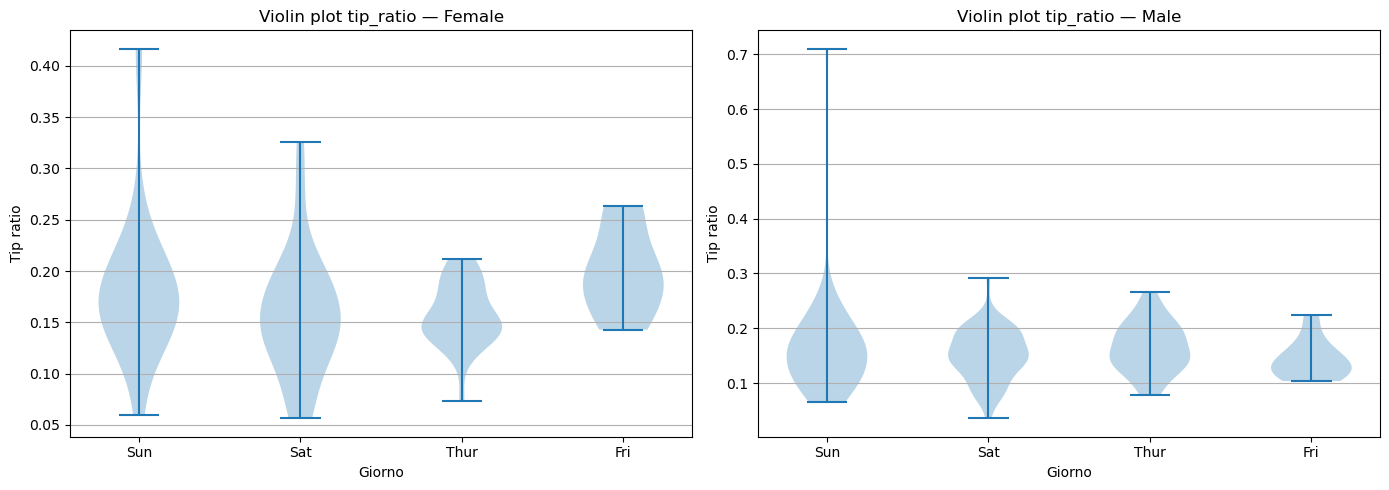

In [17]:
# 1. Righe e colonne
print(f"Righe: {tips.shape[0]}, Colonne: {tips.shape[1]}")
tips = tips.drop(columns=['time'])

# 2. Giorno più frequente
print(f"\nGiorno più frequente: {tips['day'].value_counts().idxmax()}")

# 3. Media total_bill per giorno ordinata
media_giorno = tips.groupby('day')['total_bill'].mean().sort_values()
print(f"\nMedia total_bill per giorno:\n{media_giorno}")

# 4. Boxplot tip per giorno (+ sesso)
giorni = tips['day'].unique()
sessi = tips['sex'].unique()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, sesso in zip(axes, sessi):
    data = [tips[(tips['day'] == g) & (tips['sex'] == sesso)]['tip'].values for g in giorni]
    ax.boxplot(data, labels=giorni)
    ax.set_title(f'Boxplot tip — {sesso}')
    ax.set_xlabel('Giorno')
    ax.set_ylabel('Tip')
    ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

# 5. Violin plot tip_ratio per giorno (+ sesso)
tips['tip_ratio'] = tips['tip'] / tips['total_bill']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, sesso in zip(axes, sessi):
    data = [tips[(tips['day'] == g) & (tips['sex'] == sesso)]['tip_ratio'].values for g in giorni]
    ax.violinplot(data, positions=range(len(giorni)))
    ax.set_xticks(range(len(giorni)))
    ax.set_xticklabels(giorni)
    ax.set_title(f'Violin plot tip_ratio — {sesso}')
    ax.set_xlabel('Giorno')
    ax.set_ylabel('Tip ratio')
    ax.grid(True, axis='y')
plt.tight_layout()
plt.show()


## Esercizio 6

Hai a disposizione il dataset di coppie `(x, y)` qui sotto riportato.  

1. Stima i parametri della retta del tipo  

   \[
   y = a \cdot x + b
   \]  

2. Plotta i punti originali e la retta ottenuta.  

3. Calcola **MAE** (Mean Absolute Error) e **RMSE** (Root Mean Squared Error) tra i valori reali `y` e quelli stimati dal modello, dove:  

   $$
   \text{MAE} = \frac{1}{n}\sum_{i=1}^{n} \lvert y_i - \hat{y}_i \rvert
   $$  

   $$
   \text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
   $$  